In [ ]:
import pandas as pd
import numpy as np
from statistics import mode, multimode
import string

from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag
from nltk.stem import SnowballStemmer, WordNetLemmatizer
from nltk.probability import FreqDist
from nltk.classify import NaiveBayesClassifier, accuracy

from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import random
import seaborn as sns
import matplotlib.pyplot as plt
import json

## Load the Preprocessed Data

In [ ]:
dataset = pd.read_csv('../Dataset/(Preprocessed)Emotion_classify_Data(Labeled).csv')
dataset

,Comment,Emotion
0,i seriously hate one subject to death but now ...,fear
1,im so full of life i feel appalled,anger
2,i sit here to write i start to dig out my feel...,fear
3,ive been really angry with r and i feel like a...,joy
4,i feel suspicious if there is no one outside l...,fear
...,...,...
5929,i begun to feel distressed for you,fear
5930,i left feeling annoyed and angry thinking that...,anger
5931,i were to ever get married i d have everything...,joy
5932,i feel reluctant in applying there because i w...,fear


In [ ]:
from thePreprocessingII import preProcess

stopsList = stopwords.words('english')
punctList = string.punctuation
stemmer = SnowballStemmer('english')
lemmatizer = WordNetLemmatizer()

def getLabel(tag):
    if tag == 'jj': return 'a'
    elif tag in ['vb', 'nn', 'rb']: return tag[0]
    else: return None

def preProcess(wordList):
    wordList = [w for w in wordList if w not in stopsList]
    wordList = [w for w in wordList if w not in punctList]
    wordList = [w for w in wordList if w.isalpha()]
    wordList = [stemmer.stem(w) for w in wordList]

    lemmaList = []
    for word, tag in pos_tag(wordList):
        label = getLabel(tag)
        if label != None: lemmaList.append(lemmatizer.lemmatize(word, label))
        else: lemmaList.append(lemmatizer.lemmatize(word))

    return lemmaList

In [ ]:
commentList = dataset['Comment'].to_list()
emotionList = dataset['Emotion'].to_list()

In [ ]:
# Load list from file
with open('../Dataset/(PreprocessedII)sentList.json', 'r') as f:
    sentList = json.load(f)

wordlister = []
for sentence in sentList:
    words = sentence.split(' ')
    for word in words:
        wordlister.append(word)

wordlister

['serious',
 'hate',
 'one',
 'subject',
 'death',
 'feel',
 'reluct',
 'drop',
 'im',
 'full',
 'life',
 'feel',
 'appal',
 'sit',
 'write',
 'start',
 'dig',
 'feel',
 'think',
 'afraid',
 'accept',
 'possibl',
 'might',
 'make',
 'ive',
 'realli',
 'angri',
 'r',
 'feel',
 'like',
 'idiot',
 'trust',
 'first',
 'place',
 'feel',
 'suspici',
 'one',
 'outsid',
 'like',
 'raptur',
 'happen',
 'someth',
 'feel',
 'jealous',
 'becasu',
 'want',
 'kind',
 'love',
 'true',
 'connect',
 'two',
 'soul',
 'want',
 'friend',
 'mine',
 'keep',
 'tell',
 'morbid',
 'thing',
 'happen',
 'dog',
 'final',
 'fell',
 'asleep',
 'feel',
 'angri',
 'useless',
 'still',
 'full',
 'anxieti',
 'feel',
 'bit',
 'annoy',
 'antsi',
 'good',
 'way',
 'feel',
 'like',
 'regain',
 'anoth',
 'vital',
 'part',
 'life',
 'live',
 'feel',
 'bit',
 'like',
 'franz',
 'liebkind',
 'produc',
 'mani',
 'peopl',
 'know',
 'fuhrer',
 'terrif',
 'dancer',
 'feel',
 'start',
 'didnt',
 'want',
 'move',
 'much',
 'realli',

In [ ]:
wordList = FreqDist(wordlister)
wordList

FreqDist({'feel': 6230, 'like': 1012, 'im': 942, 'get': 402, 'go': 361, 'time': 360, 'want': 358, 'know': 349, 'make': 343, 'littl': 326, ...})

In [ ]:
labeledData = list(zip(commentList, emotionList))

featureList = []
for sentence, label in labeledData:
    checklist = word_tokenize(sentence.lower())
    checklist = preProcess(checklist)

    features = {}
    for word in wordList:
        features[word] = (word in checklist)

    featureList.append((features, label))

In [ ]:
# featureList

## Naive Bayes Part

In [ ]:
random.shuffle(featureList)
idxData = int(len(featureList)*0.8)
trainData = featureList[:idxData]
testData = featureList[idxData:]

classifier = NaiveBayesClassifier.train(trainData)

# Compute Accuracy
acc = accuracy(classifier, testData)

classifier.show_most_informative_features(n=5)
print(f'Accuracy: {acc}')

Most Informative Features
                   scare = True             fear : joy    =     41.1 : 1.0
                 terrifi = True             fear : joy    =     39.0 : 1.0
                   unsur = True             fear : anger  =     34.7 : 1.0
                  vulner = True             fear : joy    =     33.6 : 1.0
                paranoid = True             fear : anger  =     32.0 : 1.0
Acc: 0.8812131423757371


In [ ]:
# Make predictions on the test data
predicted_labels = [classifier.classify(features) for features, label in testData]
true_labels = [label for features, label in testData]

# Compute confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[357  26  11]
 [ 23 343  12]
 [ 28  41 346]]


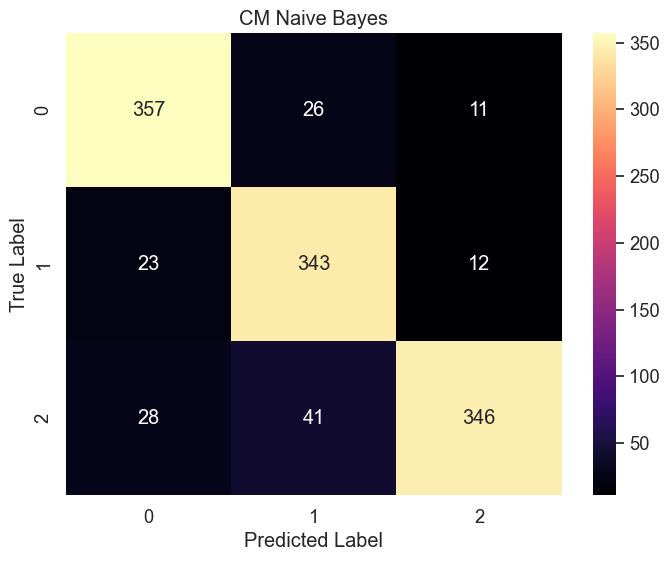

In [ ]:
# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)
sns.heatmap(conf_matrix, annot=True, cmap='magma', fmt='g', xticklabels=True, yticklabels=True)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('CM Naive Bayes')
plt.show()

In [ ]:
# Compute precision, recall, and F1 score
precision = precision_score(true_labels, predicted_labels, average='weighted')
recall = recall_score(true_labels, predicted_labels, average='weighted')
f1 = f1_score(true_labels, predicted_labels, average='weighted')

# Print evaluation metrics
print(f'Accuracy: {acc}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')

Accuracy: 0.8812131423757371
Precision: 0.8846773880544198
Recall: 0.8812131423757371
F1 Score: 0.8813312267889719


In [ ]:
testDrive = "It was so frightening"
print(f'Sentence: {testDrive}')
print(f'Emotion: {classifier.classify(FreqDist(preProcess(word_tokenize(testDrive))))}')

Sentence: It was so frightening
Emotion: fear
